




COMPARING THE STARVED LARVAE FROM THE FED-STARVED CONDITIONA ND THE STARVED-STARVED CONDIITON
STARVED LARVA EONLY 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_contacts_kinematics_over_time.csv')
df1['Condition'] = 'GH Fed-Starved'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/head_head_contacts_kinematics_over_time.csv')
df2['Condition'] = 'SI Fed-Starved'



# ---- REAL STARVED-STARVED ----
df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/head_head_contacts_kinematics_over_time.csv')
df3['Condition'] = 'GH Starved-Starved'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/head_head_contacts_kinematics_over_time.csv')
df4['Condition'] = 'SI Starved-Starved'


# combine all
df = pd.concat([df1, df2, df3, df4], ignore_index=True)


df['role'] = df['track_id'].map({0: 'starved', 1: 'fed'})
df.loc[df['Condition'].str.contains('Starved-Starved'), 'role'] = 'starved'

df['interaction_group'] = np.where(df['interaction_number'] == 1, 'first', 'other')

df = df.sort_values(['Condition','file', 'track_id', 'rel_frame'])

df['heading_angle_change'] = (
    df.groupby(['Condition', 'file', 'track_id'])['heading_angle']
      .diff()
      .abs()
)

df = df[df['role'] == 'starved'].copy()

si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()

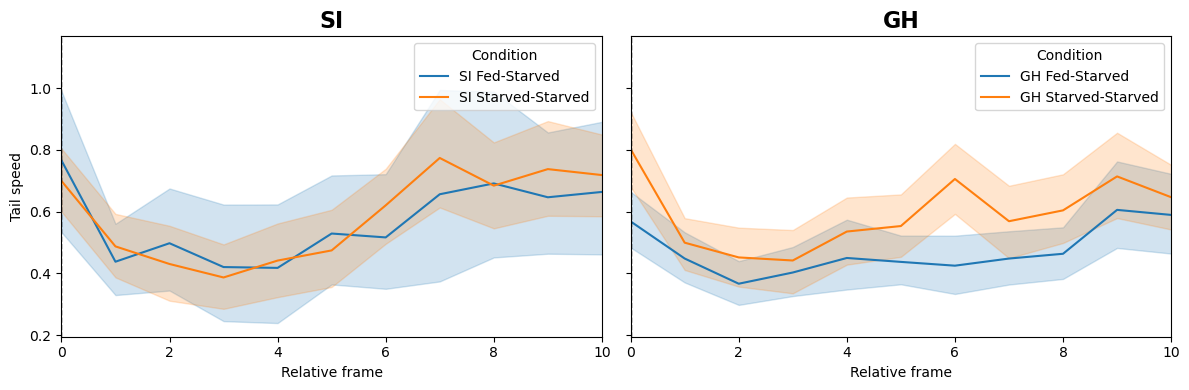

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlim(0,10)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('Tail speed')

# ---------------- GH ----------------
sns.lineplot(
    data=gh,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlim(0,10)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

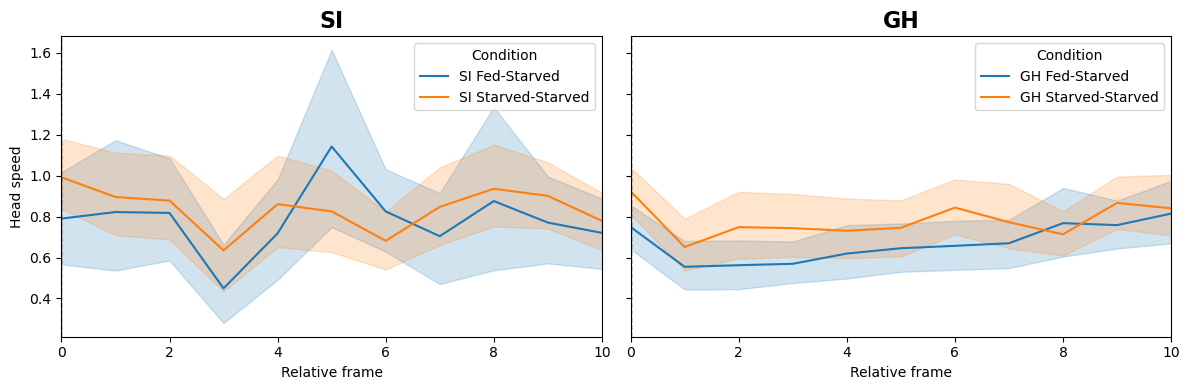

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si,
    x='rel_frame',
    y='speed_head',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlim(0,10)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('Head speed')

# ---------------- GH ----------------
sns.lineplot(
    data=gh,
    x='rel_frame',
    y='speed_head',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlim(0,10)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

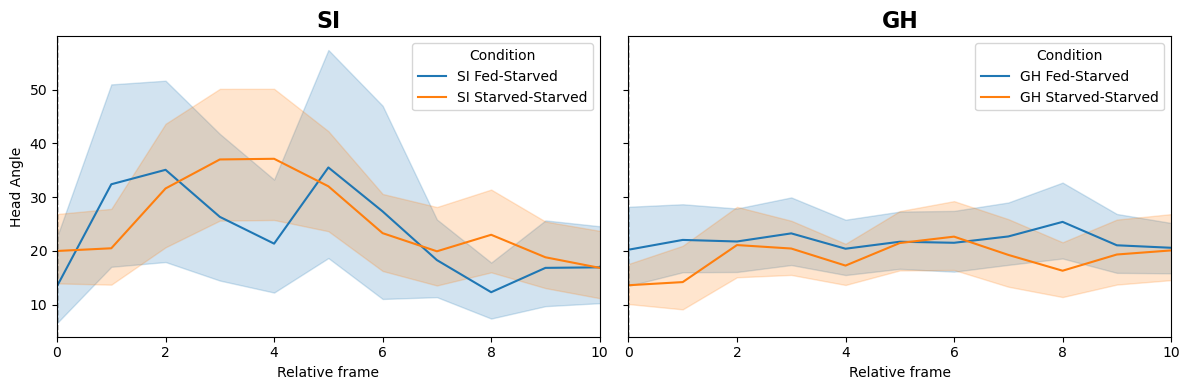

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# ---------------- SI ----------------
sns.lineplot(
    data=si,
    x='rel_frame',
    y='heading_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlim(0,10)
axes[0].set_title('SI', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Relative frame')
axes[0].set_ylabel('Head Angle')

# ---------------- GH ----------------
sns.lineplot(
    data=gh,
    x='rel_frame',
    y='heading_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlim(0,10)
axes[1].set_title('GH', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Relative frame')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()